### Multivariate Linear Regression from scratch using numpy
## (X has many features)
This project implements multivariate linear regression from scratch using NumPy.
It includes cost function, gradient computation, and gradient descent optimization without using ML libraries like Scikit-learn.

X(2-D ndarray): **m** rows of data, with **n** cols of features
Y(1-D ndarray): **m** rows of actual values, for each row of X
W(2-D ndarray): **n** one for each of feature in X
b(scalar): a single value

`X      # (m, n) m samples with n features each` <br>
`y      # (m,) target values` <br>
`W      # (n,) parameters / weights` <br>
`b      # scalar parameter / bias` <br>
`y_pred # (m,) predicted values of y` <br>
`error  # (m,) y_pred - y ` <br>
`dj_dw  # (n,) derivative of cost w.r.t. weight` <br>
`dj_db  # scalar derivative of cost w.r.t. bias` <br>

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Load Data

help(np.random.randint)

In [2]:
# Data picked from Kaggle : Multiple Linear Regression Dataset
# It is a dataset of 20 rows and 3 cols 
# Columns: age, experience, income

data = np.loadtxt('./multiple_linear_regression_dataset.csv', delimiter=',', skiprows=1)
print(f'Data shape: {data.shape}')
X = data[:, :2]
print(f'X: \n {X}')
y = data[:, -1]
print(f'y: \n {y}')

Data shape: (20, 3)
X: 
 [[25.  1.]
 [30.  3.]
 [47.  2.]
 [32.  5.]
 [43. 10.]
 [51.  7.]
 [28.  5.]
 [33.  4.]
 [37.  5.]
 [39.  8.]
 [29.  1.]
 [47.  9.]
 [54.  5.]
 [51.  4.]
 [44. 12.]
 [41.  6.]
 [58. 17.]
 [23.  1.]
 [44.  9.]
 [37. 10.]]
y: 
 [30450. 35670. 31580. 40130. 47830. 41630. 41340. 37650. 40250. 45150.
 27840. 46110. 36720. 34800. 51300. 38900. 63600. 30870. 44190. 48700.]


In [3]:

def plot_data(X, y):
    '''
        Use graph plotting for multi featured X
    '''
    
    fig, axes = plt.subplots(1, X.shape[1], figsize=(12,4), sharey=True)
    
    for i in range(X.shape[1]):
        axes[i].scatter(X[:, i], y)
        axes[i].set_title(f'Feature X[{i+1}]')
        axes[i].set_xlabel(f"X[{i+1}]")
        axes[i].set_ylabel('y')

    plt.show()


def plot_simple(x, y, xlabel="x", ylabel="y"):
    '''
        Simple plotting x vs y
    '''

    plt.plot(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


In [4]:
# some ways to create your own data 

# x = np.arange(20).reshape(-1,4)
# X = np.random.uniform(-1,1, 20).reshape(-1, 4)
# X = np.random.rand(20).reshape(-1, 4)

# Taking large values to show scaling/normalization later on
'''

X = np.random.randint(1000,size=20)
print(X.shape)
X = X.reshape(-1,4)
print(X.shape)
print(f'X: \n {X}')

y = np.random.rand(X.shape[0])
print(f'y: \n {y}')

'''

"\n\nX = np.random.randint(1000,size=20)\nprint(X.shape)\nX = X.reshape(-1,4)\nprint(X.shape)\nprint(f'X: \n {X}')\n\ny = np.random.rand(X.shape[0])\nprint(f'y: \n {y}')\n\n"

## See your data 

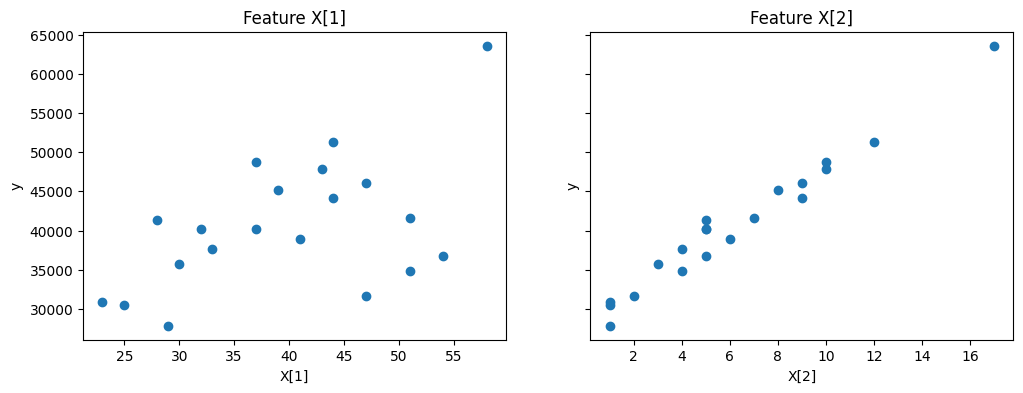

In [5]:
# plot before X is scaled
plot_data(X, y)

## Feature Scaling / Standardization
Feature scaling using mean normalization

In [6]:

def scale_X(X):
    '''
        Scale the values of X using mean normalization, along the columns

        Args:
            X (ndarray): Size(m,n) numpy array to be scaled

        Returns:
            X (ndarray): Size(m,n) scaled numpy array
    '''
    
    X_mean = np.mean(X, axis=0)
    X_range = np.max(X, axis=0) - np.min(X, axis=0)
    X = (X - X_mean ) / X_range
    
    return X

In [7]:
X = scale_X(X)
X

array([[-0.41857143, -0.325     ],
       [-0.27571429, -0.2       ],
       [ 0.21      , -0.2625    ],
       [-0.21857143, -0.075     ],
       [ 0.09571429,  0.2375    ],
       [ 0.32428571,  0.05      ],
       [-0.33285714, -0.075     ],
       [-0.19      , -0.1375    ],
       [-0.07571429, -0.075     ],
       [-0.01857143,  0.1125    ],
       [-0.30428571, -0.325     ],
       [ 0.21      ,  0.175     ],
       [ 0.41      , -0.075     ],
       [ 0.32428571, -0.1375    ],
       [ 0.12428571,  0.3625    ],
       [ 0.03857143, -0.0125    ],
       [ 0.52428571,  0.675     ],
       [-0.47571429, -0.325     ],
       [ 0.12428571,  0.175     ],
       [-0.07571429,  0.2375    ]])

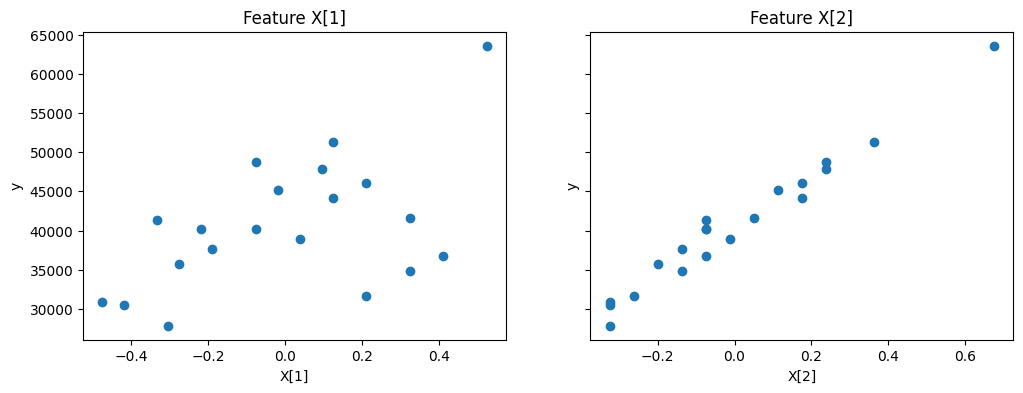

In [8]:
# plot after X is scaled
plot_data(X, y)

In [9]:
W = np.random.uniform(-1,1, X.shape[1])
b = 2

## Compute Cost

In [10]:
# Cost funtion : mean squared error
def compute_cost(X, y, W, b):
    """
    Computes cost for multivariate linear regression.

    Args:
        X (ndarray): Shape (m, n), input features
        y (ndarray): Shape (m,), target values
        w (ndarray): Shape (n,), model weights
        b (float): Bias term

    Returns:
        cost (float): calculated by using Mean Squared Error
    """
    
    m = X.shape[0]
    y_pred = np.dot(X,W) + b
    error = y_pred - y
    cost = np.sum(np.square(error)) / (2*m)

    return cost

## Compute Gradient

In [11]:
def compute_gradient(X, y, W, b):
    """
    Computes gradients for multivariate linear regression.

    Args:
        X (ndarray): Shape (m, n), input features
        y (ndarray): Shape (m,), target values
        W (ndarray): Shape (n,), model weights
        b (float): Bias term

    Returns:
        dj_dw (ndarray): Shape (n,), gradient w.r.t. w
        dj_db (float): Gradient w.r.t. b

    Note: 
        derivative of cost(J) w.r.t. w take dot product of 
        X transpose and error
    """
    
    
    m = X.shape[0]

    # Predictions
    y_pred = np.dot(X,W) + b

    # Errors
    error = y_pred - y

    # Gradients; derivatives of J wrt w and b
    dj_dw = np.dot(X.T, error) / m  # (X.T @ error) / m
    dj_db = np.sum(error) / m  # np.mean(error)

    return dj_dw, dj_db

## Why transpose of X
When doing np.dot(A,B)  <br>
A (m,n) and B (n,p) => Resultant shape of dot product (m,p)  <br>
Remember for dot product the **inner shape of A and B should be the same**  <br>
A.B **not equals to** B.A  <br>

To calculate prediction we took <br>
X(m,n) dot w(n,) the result (m,)  dot ptoduct worked here as inner shapes are same<br>
but for dj_dw we are taking transpose of X. Why?<br>
X(m,n) dot error(m,) cannot be done as **inner shapes are not same**  <br>
thus a transpose of X  <br>
X.T(n,m) dot error(m,) so result (n,) .... which is the shape of w(n,)  <br>

## Compute Gradient Descent

In [12]:
def compute_gradient_descent(X, y, W, b, alpha = 0.001, iterations = 1000, epsilon = 0.01):
    """
    Computes Gradient Descent for multivariate liner regression

    Args: 
        X (ndarray): Shape (m,n), input features
        Y (ndarray): Shape (m,), target values
        W (ndarray): Shape (n,), model weights
        b (float): Bias term
        alpha (float): Learning rate
        iterations (int):  How many tomes you want to run the gradient descent to minimize cost
        epsilon (float): approximate minimam cost which you want to reach

    Returns:
        W (ndarray): Shape (n,) final weights for global minima
        b (float): final bias term for global minima
        cost_history (list): List of all the computed costs, used for plotting
        cycles (int): After how many iterations cost was min cost was reached
    """

    cost_history = []
    
    for i in range(iterations):
        cost = compute_cost(X,y,W,b)
        cost_history.append(cost)

        # break the look if target global minima is reached
        if cost < epsilon:
            break
        dj_dw, dj_db = compute_gradient(X,y,W,b)
        W -= alpha * dj_dw
        b -= alpha * dj_db
        cycles = i+1
    
    return W, b, cost_history, cycles

## Results

cost: 839063566.8746872
dj_dw: [-168.40049385 -910.20443461] 
dj_db: -40733.5
Final W: [  224.35939215 30179.96446615] ,
Final b: 40735.49999999964
So the cost came from 839063566.87 to 1211056.24 after 5000 iterations
Linear Regression Model is y = wx + b


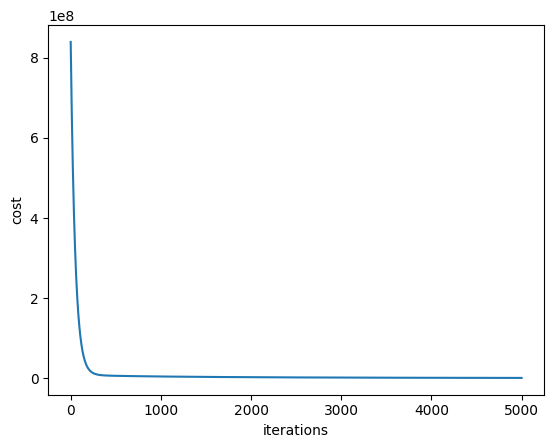

In [30]:
cost = compute_cost(X, y, W, b)
print(f'cost: {cost}')

dj_dw, dj_db = compute_gradient(X,y,W,b)
print(f'dj_dw: {dj_dw} \ndj_db: {dj_db}')

final_W, final_b, cost_history, cycles = compute_gradient_descent(X,y,W,b, alpha=0.01, iterations=5000, epsilon=0.08)
print(f'Final W: {final_W} ,\nFinal b: {final_b}')

print(f'So the cost came from {cost_history[0]:.2f} to {cost_history[-1]:.2f} after {cycles} iterations')

print(f'Linear Regression Model is y = wx + b')
#print(f'Linear Regression Model is y = w1x1 + w2x2 + w3x3 + w4x4 + b ; here number of features are 4 so we have 4 weights')
#print(f'Linear Regression Model is y = {final_W[0]:.2f}x1 + {final_W[1]:.2f}x2 + {final_W[2]:.2f}x3+ {final_W[3]:.2f}x4 + {final_b:.2f}')

plot_simple( range(len(cost_history)), cost_history, "iterations", "cost" )

In [31]:
y_pred = X @ final_W + final_b

# Viewing first 5 values of actual y and predicted y
print(f'y actual: {y[:5]}')
print(f'y predicted: {y_pred[:5]}')

y actual: [30450. 35670. 31580. 40130. 47830.]
y predicted: [30833.10111722 34637.64801722 32860.37479999 38422.96411218
 47924.71595967]


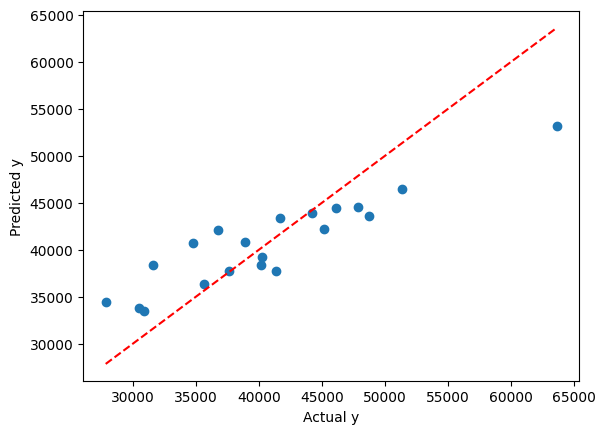

In [26]:
# plot linear model

plt.scatter(y, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()


In [27]:
def predict_y(X, W, b ):
    '''
        Predict the value for new row of features, where W and b were already calculated
        to minimize the cost
        Args:
            X (ndarray) : Shape (m,n) new features for which values are to be predicted
            W (ndarray) : Shape (n,) array of final weights
            b (scalar) : (float) value of final bias
        Returns:
            y (scalar) : (float) predicted value 
    '''

    X = scale_X(X)
    y = W@X + b

    return y
    

In [28]:
test_X = np.array([32, 7])
predicted_y = predict_y(test_X, final_W, final_b)
print(predicted_y)

36792.2957033356
